# NMF Topic Models

Topic modelling aims to automatically discover the hidden thematic structure in a large corpus of text documents. One approach for topic modelling is to apply *matrix factorisation* methods, such as *Non-negative Matrix Factorisation (NMF)*. In this notebook we look at how to apply NMF using the *scikit-learn* library in Python.

### Applying NMF

First, let's load the TF-IDF normalised document-term matrix and list of terms that we stored earlier using *Joblib*:

In [1]:
from sklearn.externals import joblib
(A,terms,snippets) = joblib.load( "articles-tfidf.pkl" )
print( "Loaded %d X %d document-term matrix" % (A.shape[0], A.shape[1]) )

Loaded 8894 X 33461 document-term matrix


The key input parameter to NMF is the number of topics to generate *k*. For the moment, we will pre-specify a guessed value, for demonstration purposes.

In [3]:
k = 25

Another choice for NMF revolves around initialisation. Most commonly, NMF involves using random initialisation to populate the values in the factors W and H. Depending on the random seed that you use, you may get different results on the same dataset. Instead, using SVD-based initialisation provides more reliable results.

In [4]:
# create the model
from sklearn import decomposition
model = decomposition.NMF( init="nndsvd", n_components=k ) 
# apply the model and extract the two factor matrices
W = model.fit_transform( A )
H = model.components_

### Examining the Output

NMF produces to factor matrices as its output: *W* and *H*.

The *W* factor contains the document membership weights relative to each of the *k* topics. Each row corresponds to a single document, and each column correspond to a topic.

In [5]:
W.shape

(8894, 25)

For instance, for the first document, we see that it is strongly associated with one topic. However,  each document can be potentially associated with multiple topics to different degrees.

In [6]:
# round to 2 decimal places for display purposes
W[0,:].round(2)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.])

The *H* factor contains the term weights relative to each of the *k* topics. In this case, each row corresponds to a topic, and each column corresponds to a unique term in the corpus vocabulary.

In [7]:
H.shape

(25, 33461)

For instance, for the term "brexit", we see that it is strongly associated with a single topic. Again, in some cases each term can be associated with multiple topics.

In [8]:
term_index = terms.index('brexit')
# round to 2 decimal places for display purposes
H[:,term_index].round(2)

array([0.  , 0.  , 0.  , 0.42, 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  ])

### Topic Descriptors

The top ranked terms from the *H* factor for each topic can give us an insight into the content of that topic. This is often called the *topic descriptor*. Let's define a function that extracts the descriptor for a specified topic: 

In [9]:
import numpy as np
def get_descriptor( terms, H, topic_index, top ):
    # reverse sort the values to sort the indices
    top_indices = np.argsort( H[topic_index,:] )[::-1]
    # now get the terms corresponding to the top-ranked indices
    top_terms = []
    for term_index in top_indices[0:top]:
        top_terms.append( terms[term_index] )
    return top_terms

We can now get a descriptor for each topic using the top ranked terms (e.g. top 10):

In [10]:
descriptors = []
for topic_index in range(k):
    descriptors.append( get_descriptor( terms, H, topic_index, 10 ) )
    str_descriptor = ", ".join( descriptors[topic_index] )
    print("Topic %02d: %s" % ( topic_index+1, str_descriptor ) )

Topic 01: people, women, life, time, book, love, something, times, day, film
Topic 02: trump, republican, campaign, donald, republicans, party, cruz, presidential, nominee, voters
Topic 03: warriors, curry, game, cavaliers, james, kerr, cleveland, finals, golden, games
Topic 04: european, britain, union, europe, british, vote, brexit, referendum, bloc, leave
Topic 05: police, officers, officer, shooting, department, gun, city, shot, authorities, people
Topic 06: company, bank, financial, business, companies, investors, banks, money, investment, volkswagen
Topic 07: graduated, bride, groom, father, university, married, york, mother, son, couple
Topic 08: clinton, sanders, democratic, campaign, voters, primary, obama, hillary, senator, bernie
Topic 09: mets, collins, harvey, inning, syndergaard, game, innings, season, wright, run
Topic 10: article, nytimes, misstated, com, 556, 698, mailed, 212, incorrectly, 844
Topic 11: islamic, obama, government, united, military, syria, forces, secur

The rankings above do not show the strength of association for the different terms. We can represent the distribution of the weights for the top terms in a topic using a *matplotlib* horizontal bar chart.

In [13]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.style.use("ggplot")
matplotlib.rcParams.update({"font.size": 14})

Define a function to create a bar chart for the specified topic, based on the *H* factor from the current NMF model:

In [14]:
def plot_top_term_weights( terms, H, topic_index, top ):
    # get the top terms and their weights
    top_indices = np.argsort( H[topic_index,:] )[::-1]
    top_terms = []
    top_weights = []
    for term_index in top_indices[0:top]:
        top_terms.append( terms[term_index] )
        top_weights.append( H[topic_index,term_index] )
    # note we reverse the ordering for the plot
    top_terms.reverse()
    top_weights.reverse()
    # create the plot
    fig = plt.figure(figsize=(13,8))
    # add the horizontal bar chart
    ypos = np.arange(top)
    ax = plt.barh(ypos, top_weights, align="center", color="green",tick_label=top_terms)
    plt.xlabel("Term Weight",fontsize=14)
    plt.tight_layout()
    plt.show()

So for instance, for the 7th topic we can generate a plot with the top 15 terms using:

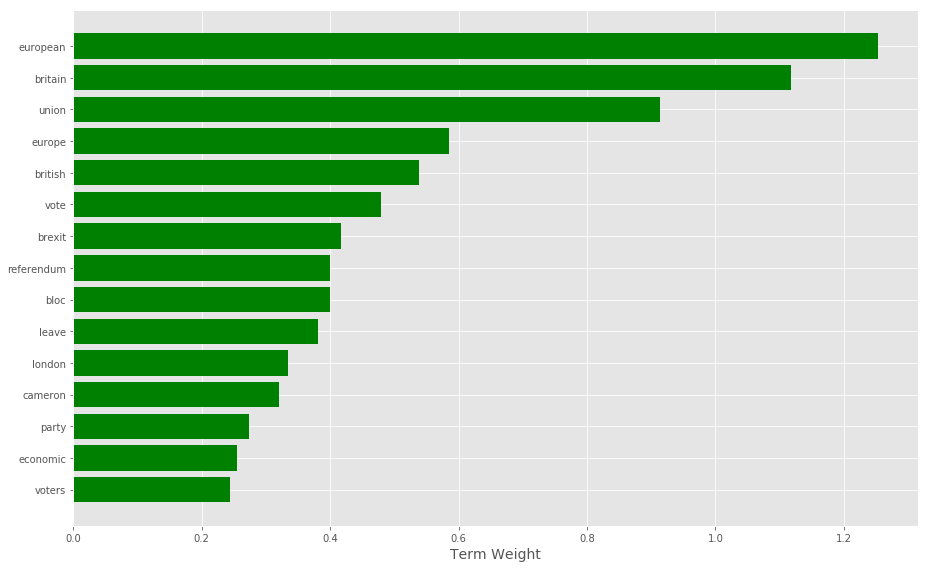

In [16]:
plot_top_term_weights( terms, H, 3, 15 )

### Most Relevant Documents

We can also look at the snippets for the top-ranked documents for each topic. We'll define a function to produce this ranking also.

In [18]:
def get_top_snippets( all_snippets, W, topic_index, top ):
    # reverse sort the values to sort the indices
    top_indices = np.argsort( W[:,topic_index] )[::-1]
    # now get the snippets corresponding to the top-ranked indices
    top_snippets = []
    for doc_index in top_indices[0:top]:
        top_snippets.append( all_snippets[doc_index] )
    return top_snippets

For instance, for the first topic listed above, the top 10 documents are:

In [20]:
topic_snippets = get_top_snippets( snippets, W, 3, 20 )
for i, snippet in enumerate(topic_snippets):
    print("%02d. %s" % ( (i+1), snippet ) )

01. "WASHINGTON — With a landmark vote approaching on Thursday on whether Britain will leave the Europea
02. "LONDON — Britain has voted to leave the European Union, a historic decision sure to reshape the nat
03. "BRUSSELS — Shaken by Britain’s vote to quit the European Union, the bloc’s leaders met on Tuesday i
04. "PARIS — The rest of the European Union nations are looking at the possibility of a British departur
05. "LONDON — With British politics in turmoil, there were already clear indications on Saturday of a te
06. "WASHINGTON — In the days since Britons voted to leave the European Union, the so-called “Brexit” re
07. "LONDON — Britain’s startling decision to pull out of the European Union set off a cascade of afters
08. "LONDON — If Britain wakes up on Friday morning to the news that it has voted itself out of the Euro
09. "LONDON — Politicians campaigning for and against British withdrawal from the European Union fanned 
10. "It may now be time to seriously consider what woul

Similarly, for the second topic:

In [17]:
topic_snippets = get_top_snippets( snippets, W, 1, 20 )
for i, snippet in enumerate(topic_snippets):
    print("%02d. %s" % ( (i+1), snippet ) )

01. "The future Mrs. Donald J. Trump was puzzled.She had been summoned to a lunch meeting with her husba
02. "‘Have you seen the latest polls? I’m beating Hillary.”Donald Trump was on the phone with a man he h
03. "Every week or so during the spring, I met with Reince Priebus, the chairman of the Republican Natio
04. "Democratic leaders nationwide sought to exact a political price from Republican officials and candi
05. "BRIARCLIFF MANOR, N.Y. — Donald J. Trump, aided by two teleprompters, presented the version of hims
06. "Republican elected officials, donors and strategists grappled uncomfortably on Wednesday with the i
07. "They called him a madman, a con man, a cancer and worse during an ugly nominating fight, but in the
08. "A hasty effort to make peace between Donald J. Trump and Republican Party leaders veered toward the
09. "Donald Trump has been a familiar, if intermittent, presence in this magazine for more than three de
10. "WASHINGTON — Donald J. Trump and Speaker Paul D. R

### Exporting the Results

If we want to keep this topic model for later user, we can save it using *joblib*:

In [18]:
joblib.dump((W,H,terms,snippets), "articles-model-nmf-k%02d.pkl" % k) 

['articles-model-nmf-k24.pkl']